In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib
# matplotlib.use('TkAgg')
from matplotlib import pyplot as plt

plt.rcParams['font.family']='Times New Roman'# 设置字体族，中文为微软雅黑，英文为Times New Roman
plt.rcParams['mathtext.fontset'] = 'stix' # 设置数%matplotlib qt学公式字体为stix
# import scienceplots
plt.style.use('seaborn-v0_8-paper')
# # 设置全局参数
plt.rcParams['figure.facecolor'] = 'white'  # 设置图形的背景为透明
plt.rcParams['axes.facecolor'] = 'white'    # 设置轴域的背景为透明
plt.rcParams['savefig.facecolor'] = 'white' # 保存图像时背景透明
plt.rcParams['axes.grid'] = False

In [2]:
%matplotlib inline

In [3]:
import matplotlib
print(matplotlib.get_backend())

module://matplotlib_inline.backend_inline


In [4]:
matplotlib._get_version()

'3.6.0'

In [5]:
df = pd.read_csv("basic_var.csv",index_col=0)
# df = pd.read_pickle("basic_var.pkl")
# 去除重复列
df = df.loc[:, ~df.columns.duplicated()]

# 定义高度替换规则
def replace_level(row):
    if row['place'] == 'ZS':
        return '3 m' if row['level'] == 1 else f"{row['level']}m"
    elif row['place'] == 'JH':
        return {1: '1.5 m', 2: '4 m', 3: '8 m', 4: '14 m'}.get(row['level'], f"{row['level']}m")
    elif row['place'] == 'CM':
        return {1: '1.5 m', 2: '10 m', 3: '16 m', 4: '22 m'}.get(row['level'], f"{row['level']}m")
    return f"{row['level']}m"

# 替换 level 列的值
df['level'] = df.apply(replace_level, axis=1)

In [6]:
df

,Date,place,level,NDSI,ADI,ACI,RAOQ,AnthroEnergy,rBA,BioEnergy,BI,AEI,H_pairedShannon
0,2023-09-23 22:30:00,CM,16 m,-0.976641,1.427496,339.87778,0.017437,49.610720,0.011817,0.586269,64.631180,0.576376,2.149657
1,2023-09-23 22:40:00,CM,16 m,-0.975455,1.652277,331.81220,0.017052,23.465150,0.012425,0.291551,63.759496,0.494264,2.229338
2,2023-09-23 22:50:00,CM,16 m,-0.973548,1.646109,318.25220,0.017265,37.451670,0.013403,0.501982,64.363555,0.483643,2.217352
3,2023-09-23 23:00:00,CM,16 m,-0.976475,1.727099,340.07318,0.015753,79.358536,0.011902,0.944564,64.090793,0.432585,2.231417
4,2023-09-23 23:10:00,CM,16 m,-0.958124,1.765791,341.09442,0.029282,32.733070,0.021386,0.700022,62.168898,0.401655,2.285993
...,...,...,...,...,...,...,...,...,...,...,...,...,...
606780,2023-09-23 21:40:00,CM,16 m,-0.990260,1.053934,317.22200,0.006799,57.510845,0.004894,0.281444,58.660398,0.706550,2.099177
606781,2023-09-23 21:50:00,CM,16 m,-0.974474,1.533733,314.16534,0.017237,24.191698,0.012928,0.312748,62.432953,0.550482,2.168922
606782,2023-09-23 22:00:00,CM,16 m,-0.988514,1.427808,342.92280,0.008000,126.445480,0.005776,0.730340,61.854805,0.575200,2.191768
606783,2023-09-23 22:10:00,CM,16 m,-0.983852,1.430760,366.28260,0.012319,116.097374,0.008140,0.944986,59.537996,0.563599,2.246934


In [7]:
# import numpy as np
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# from scipy import stats
# from legendkit import cat_legend, vstack, hstack, legend as lg_legend
# from legendkit.handles import LineItem
# from matplotlib.ticker import FuncFormatter, MaxNLocator, ScalarFormatter
# 
# # 创建一个新的数据副本 df_copy，这样不会影响原始数据
# df_copy = df.copy()
# 
# # 提取小时
# df_copy['Hour'] = pd.to_datetime(df_copy['Date']).dt.hour
# 
# # 定义去除极端值的函数
# def remove_outliers(df, columns):
#     z_scores = np.abs(stats.zscore(df[columns]))
#     filtered_entries = (z_scores < 3).all(axis=1)
#     return df[filtered_entries]
# 
# # 选择需要去极端值的列（除去 'Date', 'place', 'level', 'Hour'）
# columns_to_check = df_copy.columns[4:-1]  # 从第5列开始是你的变量
# 
# # 去除极端值
# df_filtered = remove_outliers(df_copy, columns_to_check)
# 
# # 获取 level 的排序
# sorted_levels = ['1.5 m', '3 m', '4 m', '8 m', '10 m', '14 m', '16 m', '22 m']
# places = df_filtered['place'].unique()
# 
# title_font = {'fontsize': 12, 'fontweight': 'bold'}
# label_font = {'fontsize': 10}
# 
# 
# plt.figure(figsize=(12, 10))
# 
# # 遍历除 'Date', 'place', 'level', 'Hour' 以外的其他列
# for i, column in enumerate(df_filtered.columns[4:-1]):  # 从第5列开始是你的变量
#     ax = plt.subplot(4, 3, i + 1)
# 
#     # 画原始数据的线
#     sns.lineplot(
#         data=df_filtered, x='Hour', y=column, hue='level', style='place', 
#         hue_order=sorted_levels,  # 按照从低到高排序
#         palette='tab10', ax=ax, legend=False, 
#         errorbar=None  ,style_order=places
#     )
#     # 计算平均值
#     mean_values = df_filtered.groupby('Hour')[column].mean()
#     # 计算置信区间
#     confidence_interval = stats.t.interval(0.9, len(mean_values)-1, loc=mean_values, scale=stats.sem(df_filtered[column]))
#     # 画平均趋势线
#     ax.plot(mean_values.index, mean_values, color='#2A4C65', lw=2.5, label='Mean Trend')
#     ax.fill_between(mean_values.index, confidence_interval[0], confidence_interval[1], color='red', alpha=0.3)
#     plt.title(f'{column}')
#     plt.xlabel('Hours (h)')
#     plt.ylabel(column)
#     plt.xticks(range(0, 24, 2))  # 每2小时显示一次刻度
# 
#     # 标题和标签美化
#     ax.set_title(f'{column}', fontdict=title_font)
#     ax.set_xlabel('Hour of the Day', fontdict=label_font)
#     ax.set_ylabel(column, fontdict=label_font)
# 
#     # 设置x轴刻度
#     ax.set_xticks(range(0, 24, 2))
# 
#     # 添加网格线
#     ax.grid(True, which='both', linestyle='--', linewidth=0.5)
# 
#     def format_ticks(x, pos):
#         return f'{x:.2f}'
#     ax.yaxis.set_major_locator(MaxNLocator(nbins=12))
#     ax.yaxis.set_major_formatter(FuncFormatter(format_ticks))
#     ax.tick_params(axis='y', labelsize=10)
#     ax.tick_params(axis='x', labelsize=10)
# 
# 
#     plt.tight_layout()
# 
#     if i==5:
#         axs=ax
# 
# 
# 
# 
# # 创建 hue 的图例项
# hue_legend_args = dict(
#     colors=sns.color_palette('tab10', len(sorted_levels)),
#     labels=[f'{level}' for level in sorted_levels],
#     title='Level',
#     alignment='center',
#     loc='center'
# )
# # 创建 style 的图例项，使用 LineItem 表示不同的线型
# line_styles = ['-', '--', ':', '-.']
# style_handles = [LineItem(linestyle=ls, color='black') for ls in line_styles]
# style_labels = [f'{place}' for place in places]
# # 创建 Mean Trend 的图例项
# mean_trend_handle = LineItem(linestyle='-', color='#2A4C65', lw=3)
# # 使用 lg_legend 函数创建组合图例
# legend1 = lg_legend(
#     handles=style_handles + [mean_trend_handle], 
#     labels=style_labels + ['Mean Trend'], 
#     ax=axs,fontsize=10
# )
# legend2 = cat_legend(**hue_legend_args, ax=axs,fontsize=10)
# # 垂直堆叠 Place 和 Mean Trend 的图例项
# vs = vstack([legend1], title="Place", loc="out right center", spacing=10, frameon=False, ax=axs)
# # 水平堆叠 Level 图例项与垂直堆叠的图例项
# hstack([legend2, vs], title="", loc="out right center", spacing=10, frameon=False, ax=axs)
# 
# 
# # plt.savefig('test.svg')
# plt.show()


In [8]:
df['place'].unique()

array(['CM', 'JH', 'ZS'], dtype=object)

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

16_JH vs. 16_CM: t-test independent samples, P_val:0.000e+00 t=7.789e+01
20_ZS vs. 20_JH: t-test independent samples, P_val:0.000e+00 t=6.002e+01
20_JH vs. 20_CM: t-test independent samples, P_val:0.000e+00 t=8.640e+01
4_ZS vs. 4_JH: t-test independent samples, P_val:0.000e+00 t=1.102e+02
4_JH vs. 4_CM: t-test independent samples, P_val:0.000e+00 t=4.835e+01
8_ZS vs. 8_JH: t-test independent samples, P_val:0.000e+00 t=1.494e+02
0_ZS vs. 0_JH: t-test independent samples, P_val:0.000e+00 t=6.358e+01
0_JH vs. 0_CM: t-test independent samples, P_val:0.000e+00 t=8.296e+01
8_JH vs. 8_CM: t-test independent samples, P_val:0.000e+00 t=5.113e+01
12_ZS vs. 12_JH: t-test independent samples, P_val:0.000e+00 t=1.400e+02
12_JH vs. 12_CM: t-test independent samples, P_val:0.000e+00 t=7.942e+01
16_ZS vs. 16_JH: t-test inde

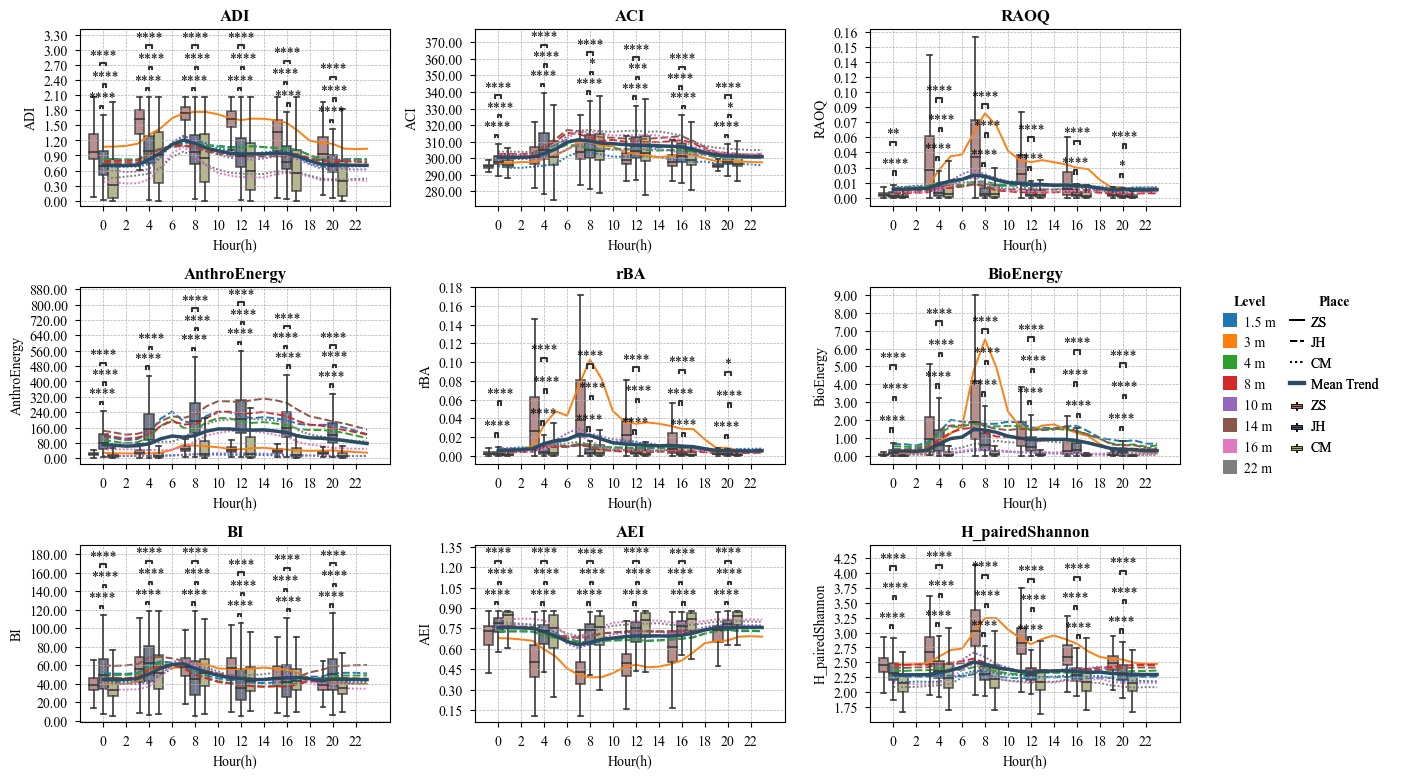

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from legendkit import cat_legend, vstack, hstack, legend as lg_legend
from legendkit.handles import LineItem,BoxplotItem
from matplotlib.ticker import FuncFormatter, MaxNLocator, ScalarFormatter


# 创建一个新的数据副本 df_copy，这样不会影响原始数据
df_copy = df.copy()
# 提取小时
df_copy['Hour'] = pd.to_datetime(df_copy['Date']).dt.hour

# 定义去除极端值的函数
def remove_outliers(df, columns):
    z_scores = np.abs(stats.zscore(df[columns]))
    filtered_entries = (z_scores < 3).all(axis=1)
    return df[filtered_entries]

# 选择需要去极端值的列（除去 'Date', 'place', 'level', 'Hour'）
columns_to_check = df_copy.columns[4:-1]  # 从第5列开始是你的变量

# 去除极端值
df_filtered =remove_outliers(df_copy, columns_to_check)

# 获取 level 的排序
sorted_levels = ['1.5 m', '3 m', '4 m', '8 m', '10 m', '14 m', '16 m', '22 m']
places = ['ZS','JH', 'CM' ]

title_font = {'fontsize': 12, 'fontweight': 'bold'}
label_font = {'fontsize': 10}
huecolor=["#AD6B6B","#4D5874","#ADAD6B"]

# 假设 N 为你想要的小时间隔，例如 3 小时
N = 4
# 确保对整个 DataFrame 进行操作，避免 SettingWithCopyWarning
df_filtered = df_filtered.copy()  # 复制 DataFrame 确保是一个独立的副本
df_filtered['Hour_Group'] = (df_filtered['Hour'] // N) * N





# 找出 Hour 中的所有唯一值
all_hours = df_filtered['Hour'].unique()
# 找出在 Hour 中有，但在 Hour_Group 中没有的小时对应的组
missing_hour_groups = set(all_hours) - set(df_filtered['Hour_Group'].unique())
# 为缺失的 Hour_Group 值创建新行，所有其他列为 NaN
missing_rows = pd.DataFrame({
    'Hour_Group': list(missing_hour_groups),
    'Hour': np.nan,  # 将 Hour 列设置为 NaN
    # 对于其他列也设置为 NaN
    **{col: np.nan for col in df_filtered.columns if col not in ['Hour', 'Hour_Group']}
})
# 创建新的 DataFrame，将原始的 df_filtered_copy 与新创建的 missing_rows 合并
new_df = pd.concat([df_filtered, missing_rows], ignore_index=True)
# 根据 Hour_Group 和 Hour 排序
new_df = new_df.sort_values(by=['Hour_Group', 'Hour']).reset_index(drop=True)

orderplot= np.unique(new_df.Hour_Group)
order =orderplot


hue_order = places
par1=[]
import itertools
for o in order:
    par2=[]
    for u in hue_order:
        par2.append((o,u))
    par2=tuple(itertools.combinations(par2,2))
    for y in par2:
        par1.append(y)




plt.figure(figsize=(12, 10))

# 遍历除 'Date', 'place', 'level', 'Hour' 以外的其他列
for i, column in enumerate(df_filtered.columns[4:-2]):  # 从第5列开始是你的变量
    
    ax = plt.subplot(4, 3, i + 1)
    
    # 画原始数据的线
    p1=sns.lineplot(
        data=df_filtered, x='Hour', y=column, hue='level', style='place', 
        hue_order=sorted_levels,  # 按照从低到高排序
        palette='tab10', ax=ax, legend=False,style_order=places, ci=None,zorder=1)
    
    # 画每 N 小时的箱线图
    p2=sns.boxplot(
        data=new_df, x='Hour_Group', y=column, hue='place', palette=huecolor, ax=ax, dodge=True, showfliers=False,linewidth=1.2,width=2.5,
          order=orderplot, hue_order=hue_order,zorder=2,boxprops=dict(alpha=0.8))
    
    
    # Re-order the collections to bring the boxplot to the top
    for artist in ax.collections:
        if isinstance(artist, plt.Line2D):
            artist.set_zorder(1)
        else:
            artist.set_zorder(2)
    
    # Update axis limits and re-scale view
    ax.relim()
    ax.autoscale_view()
    




    
    ax.set_xlim(-2, 25)  # 确保 x 轴范围一致
    
    # 计算平均值
    mean_values = df_filtered.groupby('Hour')[column].mean()
    # # 计算置信区间
    # confidence_interval = stats.t.interval(0.9, len(mean_values)-1, loc=mean_values, scale=np.std(df_filtered[column]))
    # 画平均趋势线
    ax.plot(mean_values.index, mean_values, color='#2A4C65', lw=2.5, label='Mean Trend')
    # ax.fill_between(mean_values.index, confidence_interval[0], confidence_interval[1], color='red', alpha=0.3)
    
    
    plt.title(f'{column}')
    plt.ylabel(column)
    
    # 标题和标签美化
    ax.set_title(f'{column}', fontdict=title_font)
    ax.set_xlabel('Hour(h)', fontdict=label_font)
    ax.set_ylabel(column, fontdict=label_font)
    
    # 设置x轴刻度
    ax.set_xticks(range(0, 24, 2))
    # 添加网格线
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    
    def format_ticks(x, pos):
        return f'{x:.2f}'
    ax.yaxis.set_major_locator(MaxNLocator(nbins=12))
    ax.yaxis.set_major_formatter(FuncFormatter(format_ticks))
    ax.tick_params(axis='y', labelsize=10)
    ax.tick_params(axis='x', labelsize=10)
    ax.get_legend().remove()
    
    
    
    from statannotations.Annotator import Annotator
    annot = Annotator(ax=p2, pairs=par1, x='Hour_Group', y=column, hue='place', data=new_df, hide_non_significant=True,
              order=order, hue_order=hue_order)
    annot.configure(test='t-test_ind', verbose=2, line_offset=0.05, text_offset=0.02)
    annot.apply_test()
    annot.annotate()
    
    plt.tight_layout()
    
    if i==5:
        axs=ax
        
        
# 创建 hue 的图例项
hue_legend_args = dict(
    colors=sns.color_palette('tab10', len(sorted_levels)),
    labels=[f'{level}' for level in sorted_levels],
    title='Level',
    alignment='center',
    loc='center'
)
# 创建 style 的图例项，使用 LineItem 表示不同的线型
line_styles = ['-', '--', ':']
style_handles = [LineItem(linestyle=ls, color='black') for ls in line_styles]
style_labels = [f'{place}' for place in places]

# 创建 style 的图例项，使用 BoxItem 表示不同的线型
place_handles = [BoxplotItem(fc=fc,linewidth=0.5) for fc in huecolor]
place_labels = [f'{place}' for place in places]

# 创建 Mean Trend 的图例项
mean_trend_handle = LineItem(linestyle='-', color='#2A4C65', lw=3)
# 使用 lg_legend 函数创建组合图例
legend1 = lg_legend(
    handles=style_handles+ [mean_trend_handle] +place_handles, 
    labels=style_labels+ ['Mean Trend']+place_labels , 
    ax=axs,fontsize=10
)

legend2 = cat_legend(**hue_legend_args, ax=axs,fontsize=10)
# 垂直堆叠 Place 和 Mean Trend 的图例项
vs = vstack([legend1], title="Place", loc="out right center", spacing=10, frameon=False, ax=axs)
# 水平堆叠 Level 图例项与垂直堆叠的图例项
hstack([legend2, vs], title="", loc="out right center", spacing=10, frameon=False, ax=axs)


plt.savefig('小时分层分地点变化.svg', bbox_inches='tight', pad_inches=0.1)
plt.savefig('小时分层分地点变化.png', bbox_inches='tight', pad_inches=0.1,dpi=500)
plt.show()


In [10]:
par1

[((0, 'ZS'), (0, 'JH')),
 ((0, 'ZS'), (0, 'CM')),
 ((0, 'JH'), (0, 'CM')),
 ((1, 'ZS'), (1, 'JH')),
 ((1, 'ZS'), (1, 'CM')),
 ((1, 'JH'), (1, 'CM')),
 ((2, 'ZS'), (2, 'JH')),
 ((2, 'ZS'), (2, 'CM')),
 ((2, 'JH'), (2, 'CM')),
 ((3, 'ZS'), (3, 'JH')),
 ((3, 'ZS'), (3, 'CM')),
 ((3, 'JH'), (3, 'CM')),
 ((4, 'ZS'), (4, 'JH')),
 ((4, 'ZS'), (4, 'CM')),
 ((4, 'JH'), (4, 'CM')),
 ((5, 'ZS'), (5, 'JH')),
 ((5, 'ZS'), (5, 'CM')),
 ((5, 'JH'), (5, 'CM')),
 ((6, 'ZS'), (6, 'JH')),
 ((6, 'ZS'), (6, 'CM')),
 ((6, 'JH'), (6, 'CM')),
 ((7, 'ZS'), (7, 'JH')),
 ((7, 'ZS'), (7, 'CM')),
 ((7, 'JH'), (7, 'CM')),
 ((8, 'ZS'), (8, 'JH')),
 ((8, 'ZS'), (8, 'CM')),
 ((8, 'JH'), (8, 'CM')),
 ((9, 'ZS'), (9, 'JH')),
 ((9, 'ZS'), (9, 'CM')),
 ((9, 'JH'), (9, 'CM')),
 ((10, 'ZS'), (10, 'JH')),
 ((10, 'ZS'), (10, 'CM')),
 ((10, 'JH'), (10, 'CM')),
 ((11, 'ZS'), (11, 'JH')),
 ((11, 'ZS'), (11, 'CM')),
 ((11, 'JH'), (11, 'CM')),
 ((12, 'ZS'), (12, 'JH')),
 ((12, 'ZS'), (12, 'CM')),
 ((12, 'JH'), (12, 'CM')),
 ((13, 

In [11]:
# # 创建一个新的数据副本 df_copy，这样不会影响原始数据
# df_copy = df.copy()
# df_copy['Month'] = pd.to_datetime(df_copy['Date']).dt.month
# 
# 
# # 定义去除极端值的函数
# def remove_outliers(df, columns):
#     z_scores = np.abs(stats.zscore(df[columns]))
#     filtered_entries = (z_scores < 3).all(axis=1)
#     return df[filtered_entries]
# 
# # 选择需要去极端值的列（除去 'Date', 'place', 'level', 'Hour'）
# columns_to_check = df_copy.columns[4:-1]  # 从第5列开始是你的变量
# 
# # 去除极端值
# df_filtered = remove_outliers(df_copy, columns_to_check)
# df_filtered = df_filtered.copy()
# # Safely assign a categorical month order
# df_filtered['Month'] = pd.Categorical(df_filtered['Month'], 
#                                       categories=[12, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], 
#                                       ordered=True)
# df_filtered = df_filtered.sort_values('Month')
# 
# 
# # 获取 level 的排序
# sorted_levels = ['1.5 m', '3 m', '4 m', '8 m', '10 m', '14 m', '16 m', '22 m']
# places = df_filtered['place'].unique()
# 
# title_font = {'fontsize': 12, 'fontweight': 'bold'}
# label_font = {'fontsize': 10}
# huecolor=["#AD6B6B","#4D5874","#ADAD6B"]
# 
# # 假设 N 为你想要的小时间隔，例如 3 小时
# N = 4
# # 确保对整个 DataFrame 进行操作，避免 SettingWithCopyWarning
# df_filtered = df_filtered.copy()  # 复制 DataFrame 确保是一个独立的副本
# df_filtered['Month_Group'] = df_filtered['Month']  # Group by individual months
# 
# def get_season(month):
#     if month in [12, 1, 2]:
#         return 'Winter'
#     elif month in [3, 4, 5]:
#         return 'Spring'
#     elif month in [6, 7, 8]:
#         return 'Summer'
#     else:
#         return 'Fall'
# 
# def get_season_group(month):
#     if month in [12, 1, 2]:
#         return 1+2
#     elif month in [3, 4, 5]:
#         return 4+2
#     elif month in [6, 7, 8]:
#         return 7+2
#     else:
#         return 10+2
#     
# # Mapping old month numbers to new ones
# month_mapping = {
#     12: 1, 
#     1: 2, 
#     2: 3, 
#     3: 4, 
#     4: 5, 
#     5: 6, 
#     6: 7, 
#     7: 8, 
#     8: 9, 
#     9: 10, 
#     10: 11, 
#     11: 12
# }
#     
#     
# df_filtered['Season'] = df_filtered['Month'].apply(get_season)
# df_filtered['Month_Group'] = df_filtered['Month_Group'].apply(get_season_group)
# # Apply the mapping to the Month column
# df_filtered['Month'] = df_filtered['Month'].map(month_mapping)
# 
# # 找出 Hour 中的所有唯一值
# all_month = df_filtered['Month'].unique()
# # 找出在 Hour 中有，但在 Hour_Group 中没有的小时对应的组
# missing_month_groups = set(all_month) - set(df_filtered['Month_Group'].unique())
# # 为缺失的 Hour_Group 值创建新行，所有其他列为 NaN
# missing_rows = pd.DataFrame({
#     'Month_Group': list(missing_month_groups),
#     'Month': np.nan,  # 将 Hour 列设置为 NaN
#     # 对于其他列也设置为 NaN
#     **{col: np.nan for col in df_filtered.columns if col not in ['Month', 'Month_Group']}
# })
# # 创建新的 DataFrame，将原始的 df_filtered_copy 与新创建的 missing_rows 合并
# new_df = pd.concat([df_filtered, missing_rows], ignore_index=True)
# # 根据 Hour_Group 和 Hour 排序
# new_df = new_df.sort_values(by=['Month_Group', 'Month']).reset_index(drop=True)
# 
# ordermonth=df_filtered['Month'].unique()
# # order = [2,5,8,11]
# order=ordermonth
# 
# hue_order = places
# par1=[]
# import itertools
# for o in order:
#     par2=[]
#     for u in hue_order:
#         par2.append((o,u))
#     par2=tuple(itertools.combinations(par2,2))
#     for y in par2:
#         par1.append(y)
# 
# 
# 
# 
# plt.figure(figsize=(12, 10))
# 
# # 遍历除 'Date', 'place', 'level', 'Hour' 以外的其他列
# for i, column in enumerate(df_filtered.columns[4:-3]):  # 从第5列开始是你的变量
#     
#     ax = plt.subplot(4, 3, i + 1)
#     
#     # 画原始数据的线
#     p1=sns.lineplot(
#         data=df_filtered, x='Month', y=column, hue='level', style='place', 
#         hue_order=sorted_levels,  # 按照从低到高排序
#         palette='tab10', ax=ax, legend=False,style_order=places, ci=None,zorder=1)
#     
#     # # 画每 N 小时的箱线图
#     p2=sns.boxplot(
#         data=new_df, x='Month_Group', y=column, hue='place', palette=huecolor, ax=ax, dodge=True, showfliers=False,linewidth=1.2,width=2.5,
#           order=order, hue_order=hue_order,zorder=2,boxprops=dict(alpha=0.8))
#     
#     
#     # Re-order the collections to bring the boxplot to the top
#     for artist in ax.collections:
#         if isinstance(artist, plt.Line2D):
#             artist.set_zorder(1)
#         else:
#             artist.set_zorder(2)
#     
#     # Update axis limits and re-scale view
#     ax.relim()
#     ax.autoscale_view()
#     
# 
# 
# 
# 
#     
#     # ax.set_xlim(0, 13)  # 确保 x 轴范围一致
#     
#     
#     
#     plt.title(f'{column}')
#     plt.ylabel(column)
#     
#     # 标题和标签美化
#     ax.set_title(f'{column}', fontdict=title_font)
#     ax.set_xlabel('Month', fontdict=label_font)
#     ax.set_ylabel(column, fontdict=label_font)
#     
#     # 设置x轴刻度
#     ax.set_xticks(range(1, 13))
#     ax.set_xticklabels(['Dec.','Jan.', 'Feb.', 'Mar.', 'Apr.', 'May.', 'Jun.', 'Jul.', 'Aug.', 'Sep.', 'Oct.', 'Nov.'],rotation=45)
#     # 添加网格线
#     ax.grid(True, which='both', linestyle='--', linewidth=0.5)
#     
#     def format_ticks(x, pos):
#         return f'{x:.2f}'
#     ax.yaxis.set_major_locator(MaxNLocator(nbins=12))
#     ax.yaxis.set_major_formatter(FuncFormatter(format_ticks))
#     ax.tick_params(axis='y', labelsize=10)
#     ax.tick_params(axis='x', labelsize=10)
#     ax.get_legend().remove()
#     
#     ax.axvline(3.5, color='grey', linestyle='--')  # End of Winter
#     ax.axvline(6.5, color='grey', linestyle='--')  # End of Spring
#     ax.axvline(9.5, color='grey', linestyle='--')  # End of Summer
#     
#     # # Add season labels
#     # ax.text(1.75, ax.get_ylim()[1] * 0.95, 'Winter', ha='center', va='top', fontsize=12, color='black')  # Winter
#     # ax.text(5, ax.get_ylim()[1] * 0.95, 'Spring', ha='center', va='top', fontsize=12, color='black')     # Spring
#     # ax.text(8, ax.get_ylim()[1] * 0.95, 'Summer', ha='center', va='top', fontsize=12, color='black')     # Summer
#     # ax.text(11, ax.get_ylim()[1] * 0.95, 'Autumn', ha='center', va='top', fontsize=12, color='black')    # Autumn
#     
#     
# 
#     from statannotations.Annotator import Annotator
#     annot = Annotator(ax=p2, pairs=par1, x='Month_Group', y=column, hue='place', data=new_df, hide_non_significant=True,
#               order=order, hue_order=hue_order)
#     annot.configure(test='t-test_ind', verbose=2)
#     annot.apply_test()
#     annot.annotate()
#     
#     
#     
#     plt.tight_layout()
#     # 
#     if i==5:
#         axs=ax
#         
#         
# # 创建 hue 的图例项
# hue_legend_args = dict(
#     colors=sns.color_palette('tab10', len(sorted_levels)),
#     labels=[f'{level}' for level in sorted_levels],
#     title='Level',
#     alignment='center',
#     loc='center'
# )
# # 创建 style 的图例项，使用 LineItem 表示不同的线型
# line_styles = ['-', '--', ':']
# style_handles = [LineItem(linestyle=ls, color='black') for ls in line_styles]
# style_labels = [f'{place}' for place in places]
# 
# # 创建 style 的图例项，使用 BoxItem 表示不同的线型
# place_handles = [BoxplotItem(fc=fc,linewidth=0.5) for fc in huecolor]
# place_labels = [f'{place}' for place in places]
# 
# # 使用 lg_legend 函数创建组合图例
# legend1 = lg_legend(
#     handles=style_handles+ place_handles, 
#     labels=style_labels+ place_labels , 
#     ax=axs,fontsize=10
# )
# 
# legend2 = cat_legend(**hue_legend_args, ax=axs,fontsize=10)
# # 垂直堆叠 Place 和 Mean Trend 的图例项
# vs = vstack([legend1], title="Place", loc="out right center", spacing=10, frameon=False, ax=axs)
# # 水平堆叠 Level 图例项与垂直堆叠的图例项
# hstack([legend2, vs], title="", loc="out right center", spacing=10, frameon=False, ax=axs)
# 
# plt.savefig('月份分层分地点变化.svg')
# plt.show()

In [12]:
import matplotlib.patches as patches

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

3_ZS vs. 3_JH: t-test independent samples, P_val:0.000e+00 t=1.234e+02
3_JH vs. 3_CM: t-test independent samples, P_val:0.000e+00 t=1.843e+02
6_ZS vs. 6_JH: t-test independent samples, P_val:0.000e+00 t=1.746e+02
6_JH vs. 6_CM: t-test independent samples, P_val:0.000e+00 t=8.524e+01
9_ZS vs. 9_JH: t-test independent samples, P_val:0.000e+00 t=5.168e+01
9_JH vs. 9_CM: t-test independent samples, P_val:3.959e-12 t=-6.941e+00
12_ZS vs. 12_JH: t-test independent samples, P_val:0.000e+00 t=1.064e+02
12_JH vs. 12_CM: t-test independent samples, P_val:3.930e-02 t=-2.061e+00
3_ZS vs. 3_CM: t-test independent samples, P_val:0.000e+00 t=2.373e+02
6_ZS vs. 6_CM: t-test independent samples, P_val:0.000e+00 t=1.840e+02
9_ZS vs. 9_CM: t-test independent samples, P_val:6.832e-261 t=3.536e+01
12_ZS vs. 12_CM: t-test indepen

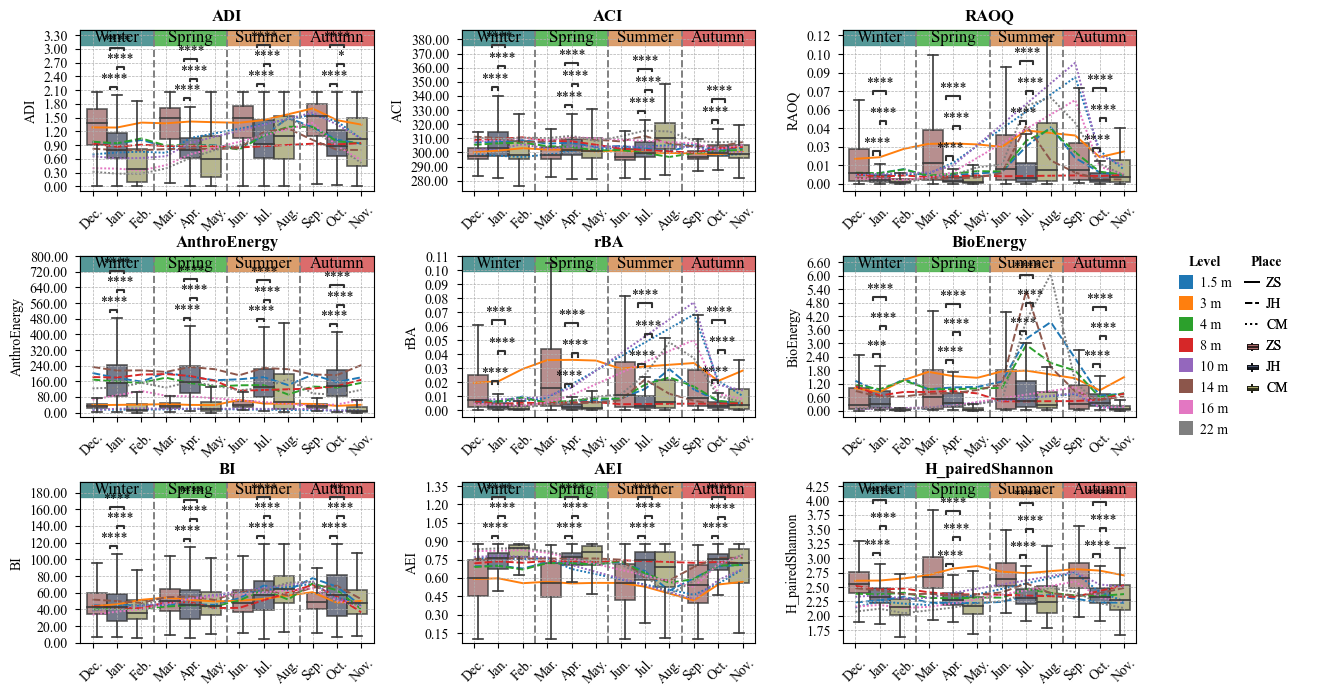

In [13]:
# 创建一个新的数据副本 df_copy，这样不会影响原始数据
df_copy = df.copy()
df_copy['Month'] = pd.to_datetime(df_copy['Date']).dt.month


# 定义去除极端值的函数
def remove_outliers(df, columns):
    z_scores = np.abs(stats.zscore(df[columns]))
    filtered_entries = (z_scores < 3).all(axis=1)
    return df[filtered_entries]

# 选择需要去极端值的列（除去 'Date', 'place', 'level', 'Hour'）
columns_to_check = df_copy.columns[4:-1]  # 从第5列开始是你的变量

# 去除极端值
df_filtered = remove_outliers(df_copy, columns_to_check)
df_filtered = df_filtered.copy()
# Safely assign a categorical month order
df_filtered['Month'] = pd.Categorical(df_filtered['Month'], 
                                      categories=[12, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], 
                                      ordered=True)
df_filtered = df_filtered.sort_values('Month')


# 获取 level 的排序
sorted_levels = ['1.5 m', '3 m', '4 m', '8 m', '10 m', '14 m', '16 m', '22 m']
places = places = ['ZS','JH', 'CM' ]

title_font = {'fontsize': 12, 'fontweight': 'bold'}
label_font = {'fontsize': 10}
huecolor=["#AD6B6B","#4D5874","#ADAD6B"]

# 假设 N 为你想要的小时间隔，例如 3 小时
N = 4
# 确保对整个 DataFrame 进行操作，避免 SettingWithCopyWarning
df_filtered = df_filtered.copy()  # 复制 DataFrame 确保是一个独立的副本
df_filtered['Month_Group'] = df_filtered['Month']  # Group by individual months

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

def get_season_group(month):
    if month in [12, 1, 2]:
        return 1+2
    elif month in [3, 4, 5]:
        return 4+2
    elif month in [6, 7, 8]:
        return 7+2
    else:
        return 10+2
    
# Mapping old month numbers to new ones
month_mapping = {
    12: 1, 
    1: 2, 
    2: 3, 
    3: 4, 
    4: 5, 
    5: 6, 
    6: 7, 
    7: 8, 
    8: 9, 
    9: 10, 
    10: 11, 
    11: 12
}
    
    
df_filtered['Season'] = df_filtered['Month'].apply(get_season)
df_filtered['Month_Group'] = df_filtered['Month_Group'].apply(get_season_group)
# Apply the mapping to the Month column
df_filtered['Month'] = df_filtered['Month'].map(month_mapping)

# 找出 Hour 中的所有唯一值
all_month = df_filtered['Month'].unique()
# 找出在 Hour 中有，但在 Hour_Group 中没有的小时对应的组
missing_month_groups = set(all_month) - set(df_filtered['Month_Group'].unique())
# 为缺失的 Hour_Group 值创建新行，所有其他列为 NaN
missing_rows = pd.DataFrame({
    'Month_Group': list(missing_month_groups),
    'Month': np.nan,  # 将 Hour 列设置为 NaN
    # 对于其他列也设置为 NaN
    **{col: np.nan for col in df_filtered.columns if col not in ['Month', 'Month_Group']}
})
# 创建新的 DataFrame，将原始的 df_filtered_copy 与新创建的 missing_rows 合并
new_df = pd.concat([df_filtered, missing_rows], ignore_index=True)
# 根据 Hour_Group 和 Hour 排序
new_df = new_df.sort_values(by=['Month_Group', 'Month']).reset_index(drop=True)

ordermonth=df_filtered['Month'].unique()
# order = [2,5,8,11]
order=ordermonth

hue_order = places
par1=[]
import itertools
for o in order:
    par2=[]
    for u in hue_order:
        par2.append((o,u))
    par2=tuple(itertools.combinations(par2,2))
    for y in par2:
        par1.append(y)




plt.figure(figsize=(12, 10))

# 遍历除 'Date', 'place', 'level', 'Hour' 以外的其他列
for i, column in enumerate(df_filtered.columns[4:-3]):  # 从第5列开始是你的变量
    
    ax = plt.subplot(4, 3, i + 1)
    
    # 画原始数据的线
    p1=sns.lineplot(
        data=df_filtered, x='Month', y=column, hue='level', style='place', 
        hue_order=sorted_levels,  # 按照从低到高排序
        palette='tab10', ax=ax, legend=False,style_order=places, ci=None,zorder=1)
    
    # # 画每 N 小时的箱线图
    p2=sns.boxplot(
        data=new_df, x='Month_Group', y=column, hue='place', palette=huecolor, ax=ax, dodge=True, showfliers=False,linewidth=1.2,width=2.5,
          order=order, hue_order=hue_order,zorder=2,boxprops=dict(alpha=0.8))
    
    
    # Re-order the collections to bring the boxplot to the top
    for artist in ax.collections:
        if isinstance(artist, plt.Line2D):
            artist.set_zorder(1)
        else:
            artist.set_zorder(2)
    
    # Update axis limits and re-scale view
    ax.relim()
    ax.autoscale_view()

    
    ax.set_xlim(0.5, 12.5)  # 确保 x 轴范围一致
    
    
    plt.title(f'{column}')
    plt.ylabel(column)
    
    # 标题和标签美化
    ax.set_title(f'{column}', fontdict=title_font)
    # ax.set_xlabel('Month', fontdict=label_font)
    ax.set_xlabel('', fontdict=label_font)
    ax.set_ylabel(column, fontdict=label_font)
    
    # 设置x轴刻度
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Dec.','Jan.', 'Feb.', 'Mar.', 'Apr.', 'May.', 'Jun.', 'Jul.', 'Aug.', 'Sep.', 'Oct.', 'Nov.'],rotation=45)
    # 添加网格线
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    
    def format_ticks(x, pos):
        return f'{x:.2f}'
    ax.yaxis.set_major_locator(MaxNLocator(nbins=12))
    ax.yaxis.set_major_formatter(FuncFormatter(format_ticks))
    ax.tick_params(axis='y', labelsize=10)
    ax.tick_params(axis='x', labelsize=10)
    ax.get_legend().remove()
    
    ax.axvline(3.5, color='grey', linestyle='--')  # End of Winter
    ax.axvline(6.5, color='grey', linestyle='--')  # End of Spring
    ax.axvline(9.5, color='grey', linestyle='--')  # End of Summer

    
    from statannotations.Annotator import Annotator
    annot = Annotator(ax=p2, pairs=par1, x='Month_Group', y=column, hue='place', data=new_df, hide_non_significant=True,
              order=order, hue_order=hue_order)
    annot.configure(test='t-test_ind', verbose=2, line_offset=0.05, text_offset=0.02)
    annot.apply_test()
    annot.annotate()
    
    y_pos = 0.9  # y position relative to the axis height
    rect_height = 0.1  # Fixed height for the rectangles
    
    # Define the positions and colors for each season
    seasons = [('Winter', 0.5, 3.5, '#2B7E7E'),   # Start, End, Color
               ('Spring', 3.5, 6.5, '#39A939'),
               ('Summer', 6.5, 9.5, '#D38647'),
               ('Autumn', 9.5, 12.5, '#D34747')]
    
    # Add a rectangle for each season
    for season, start, end, color in seasons:
        ax.add_patch(
            patches.Rectangle(
                (start, y_pos),  # (x, y) position of the rectangle
                end - start,     # width of the rectangle
                rect_height,     # height of the rectangle
                color=color,
                alpha=0.8,
                transform=ax.get_xaxis_transform(),  # Position relative to x-axis
                clip_on=False    # Draw outside the plot area
            )
        )
    
    # Optionally add labels for the seasons
    for season, start, end, color in seasons:
        ax.text((start + end) / 2, y_pos + rect_height / 2, season,
                ha='center', va='center', fontsize=12, color='black',
                transform=ax.get_xaxis_transform(), clip_on=False)

    # 
    if i==5:
        axs=ax
        
        
# 创建 hue 的图例项
hue_legend_args = dict(
    colors=sns.color_palette('tab10', len(sorted_levels)),
    labels=[f'{level}' for level in sorted_levels],
    title='Level',
    alignment='center',
    loc='center'
)
# 创建 style 的图例项，使用 LineItem 表示不同的线型
line_styles = ['-', '--', ':']
style_handles = [LineItem(linestyle=ls, color='black') for ls in line_styles]
style_labels = [f'{place}' for place in places]

# 创建 style 的图例项，使用 BoxItem 表示不同的线型
place_handles = [BoxplotItem(fc=fc,linewidth=0.5) for fc in huecolor]
place_labels = [f'{place}' for place in places]

# 使用 lg_legend 函数创建组合图例
legend1 = lg_legend(
    handles=style_handles+ place_handles, 
    labels=style_labels+ place_labels , 
    ax=axs,fontsize=10
)

legend2 = cat_legend(**hue_legend_args, ax=axs,fontsize=10)
# 垂直堆叠 Place 和 Mean Trend 的图例项
vs = vstack([legend1], title="Place", loc="out right center", spacing=10, frameon=False, ax=axs)
# 水平堆叠 Level 图例项与垂直堆叠的图例项
hstack([legend2, vs], title="", loc="out right center", spacing=10, frameon=False, ax=axs)


plt.subplots_adjust(top=0.92, bottom=0.08, left=0.07, right=0.95, hspace=0.4, wspace=0.3)

plt.savefig('月份分层分地点变化.svg', bbox_inches='tight', pad_inches=0.1)
plt.savefig('月份分层分地点变化.png', bbox_inches='tight', pad_inches=0.1,dpi=500)
plt.show()

In [14]:
np.unique(new_df["Month_Group"])

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int64)

In [15]:
df_filtered['Month'].unique()

[1, 2, 3, 4, 5, ..., 8, 9, 10, 11, 12]
Length: 12
Categories (12, int64): [1 < 2 < 3 < 4 ... 9 < 10 < 11 < 12]

In [16]:
new_df

,Date,place,level,NDSI,ADI,ACI,RAOQ,AnthroEnergy,rBA,BioEnergy,BI,AEI,H_pairedShannon,Month,Month_Group,Season
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN
2,2022-12-15 04:20:00,CM,22 m,-0.999910,0.114880,299.34120,0.000083,97.058260,0.000045,0.004380,39.267820,0.868895,1.832508,1,3,Winter
3,2022-12-11 09:30:00,ZS,3 m,-0.921390,1.845698,297.71844,0.039573,48.857426,0.040913,1.998914,47.862453,0.359699,3.057303,1,3,Winter
4,2022-12-11 09:20:00,ZS,3 m,-0.756097,2.011329,301.94418,0.113884,64.099450,0.138889,8.902738,43.402375,0.203498,3.326075,1,3,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
561190,2023-11-16 16:10:00,CM,1.5 m,-0.972611,1.656751,297.24060,0.016423,8.999923,0.013884,0.124959,60.180980,0.481731,2.493182,12,12,Fall
561191,2023-11-16 16:20:00,CM,1.5 m,-0.980889,1.593068,298.31607,0.013020,5.796791,0.009648,0.055926,57.678422,0.525909,2.407401,12,12,Fall
561192,2023-11-16 16:30:00,CM,1.5 m,-0.972888,1.844935,296.59882,0.017106,7.260456,0.013743,0.099777,53.859980,0.351321,2.534144,12,12,Fall
561193,2023-11-16 14:40:00,CM,1.5 m,-0.867042,1.815597,298.13240,0.077644,7.617835,0.071213,0.542492,59.122805,0.378731,3.116338,12,12,Fall
